# INFO-6151-(01)-26W Data Visiualization for Machine Learning

##**Assignment:05**

Student Name: Yun-Jiung Wang

Student Number: 1256222

Date: March 25nd, 2026

Description:

This Assignemnt, we are using "Predict Rain Dataset" to build a prediction model for rain.

Firstly, after the dataset was load, we will observe the data, and handle the missing columns, drop the one has high missing rate and low correlationship with the target.

After the data preprocessing was finished, we will split the data into train and test, and then we will start the training process.

Model Selection:

For the training model, we select XGBClassifier, due to its ability to handle high missing value rates (62% missing in the 'Subshine' feature), also it automatically learns complex nolinear interaction between weather features. This model ensures higher predictive accuracy while offering greater robustness and generaliztion capabilites.



Use the "Predict Rain Dataset" dataset to build a ML model for rain prediction (Please include the reason for choosing the appropriate ML model).


After preprocessing the dataset and training the model using, compute SHAP values to interpret the model's predictions.

Using the SHAP library or similar tools, create visualizations to understand the influence of different features on rain prediction.

In [7]:
# !pip install dash

### Import libs

In [8]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors  as colors
from matplotlib import cm
import matplotlib.cbook as cbook

import warnings
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import xgboost as xgb

import plotly.express as px
import plotly.graph_objects as go
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

warnings.filterwarnings('ignore') # Ignore warnings

## Load the Dataset

In [9]:
df = pd.read_csv("https://rattle.togaware.com/weatherAUS.csv")
print(df.shape)
display(df.head())

(275410, 24)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


## **Data Preprocessing**

###Convert Date to Datetime for the Cyclical Feature:

To learn the seaning change, we firstly converted the Date to Datetime, then remain only the 'Month' data.

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

df.drop(columns=['Date', 'Evaporation', 'RISK_MM'], inplace=True, errors='ignore')
df.dropna(subset=['RainTomorrow'], inplace=True)
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

###Observe missing columns

Missing Percentage per column:

Location          0.000000
MinTemp           0.503522
MaxTemp           0.366232
Rainfall          0.963276
Sunshine         61.518347
WindGustDir       6.801662
WindGustSpeed     6.728715
WindDir9am        7.590987
WindDir3pm        4.297145
WindSpeed9am      1.914955
WindSpeed3pm      3.669800
Humidity9am       1.068020
Humidity3pm       3.003924
Pressure9am      10.784200
Pressure3pm      10.783826
Cloud9am         44.999009
Cloud3pm         47.279821
Temp9am           0.486688
Temp3pm           2.458130
RainToday         0.963276
RainTomorrow      0.000000
Month             0.000000
dtype: float64


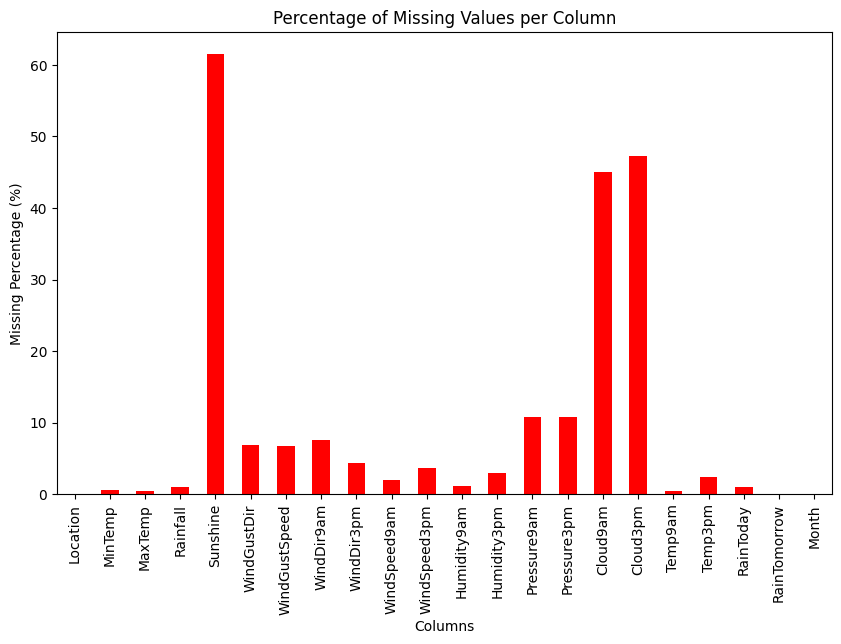

In [11]:
# Calculate the percentage of missing values
missing_percent = df.isnull().mean() * 100

print("Missing Percentage per column:\n")
print(missing_percent)

plt.figure(figsize=(10, 6))
missing_percent.plot(kind='bar',color='red')
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')
plt.show()

**Describe the Observation:**

By seeing the graph above, we could tell that there are 4 columns (Evaporation, Sunshinem Cloud9am and Cloud3pm) have high missing values.

From the table above, we can see that both Evaporation and Sunshine have a missing rate over 50%, so we are going the check the corr between these columns and the RainTomorrow (target).

We will drop the column if the corr is low, and will impute if it is high.



###Observe the Corr between RainTomorrow and Sunshine

In [12]:
target = 'RainTomorrow'

# calculate the corr bewteen Sunshine and RainTomorrow
sun_corr = df[['Sunshine', 'RainTomorrow']].corr().iloc[0, 1]
print(f"Corr of Sunshine: {sun_corr:.4f}")

Corr of Sunshine: -0.4532


**Observation:**

As the number showing above, we could see that Sunshine has a higher correlation with RainTomorrow, so we will keep this column and drop the Evapoeration.

In [13]:
# RainTomorrow is the target column, remove if there is missing
df = df.dropna(subset=[target])
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month
0,Albury,13.4,22.9,0.6,NaN,W,44.0,W,WNW,20.0,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0,12
1,Albury,7.4,25.1,0.0,NaN,WNW,44.0,NNW,WSW,4.0,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0,12
2,Albury,12.9,25.7,0.0,NaN,WSW,46.0,W,WSW,19.0,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0,12
3,Albury,9.2,28.0,0.0,NaN,NE,24.0,SE,E,11.0,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,0,12
4,Albury,17.5,32.3,1.0,NaN,W,41.0,ENE,NW,7.0,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0,12


### Handle the Missing columns:

Drop the Evaporation column due to high missing rate and RISK_MM to prevent the data leak

## Split the dataset into train and test

In [14]:
X = df.drop(target, axis=1)
y = df[target]

## Label Encoding

In [15]:
#Label Encoding Categorical column
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Impute Missing Values

In [16]:
it_imputer = IterativeImputer(max_iter=10, random_state=42)
X_train_imputed = pd.DataFrame(it_imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(it_imputer.transform(X_test), columns=X_test.columns)

## Build the model and train

In [17]:
model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## The predict result: Classification Result




In [18]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     41749
           1       0.75      0.57      0.65     11715

    accuracy                           0.87     53464
   macro avg       0.82      0.76      0.78     53464
weighted avg       0.86      0.87      0.86     53464



## Visualize the Result

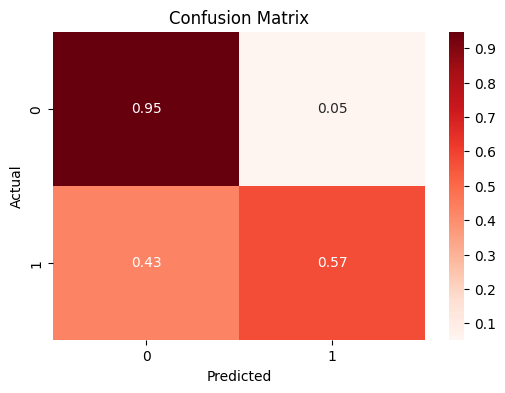

In [19]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)

cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Observation:**

The confusion matrix shows that the model predicts the TN (Correctly predict no rain, 95%) better than predict the rain (.57%).

This indicats that the model struggles to capture all precipitation events. This disparity is likely due to class imbalance in the dataset, where non-rainy days significantly outnumber rainy ones.

##SHAP Analysis

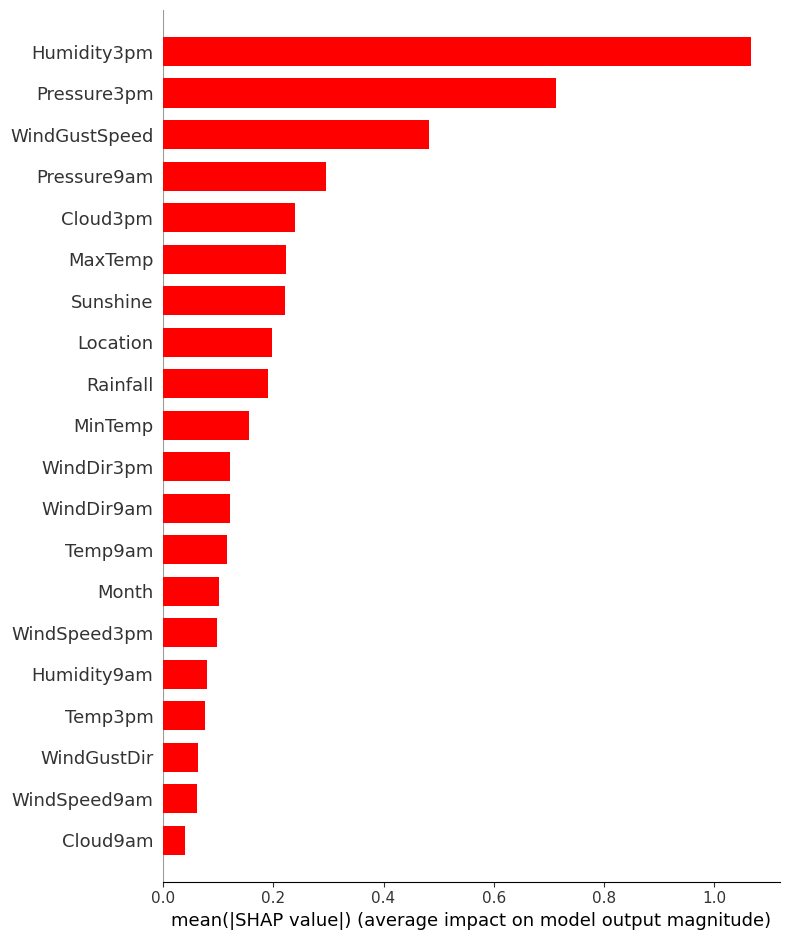

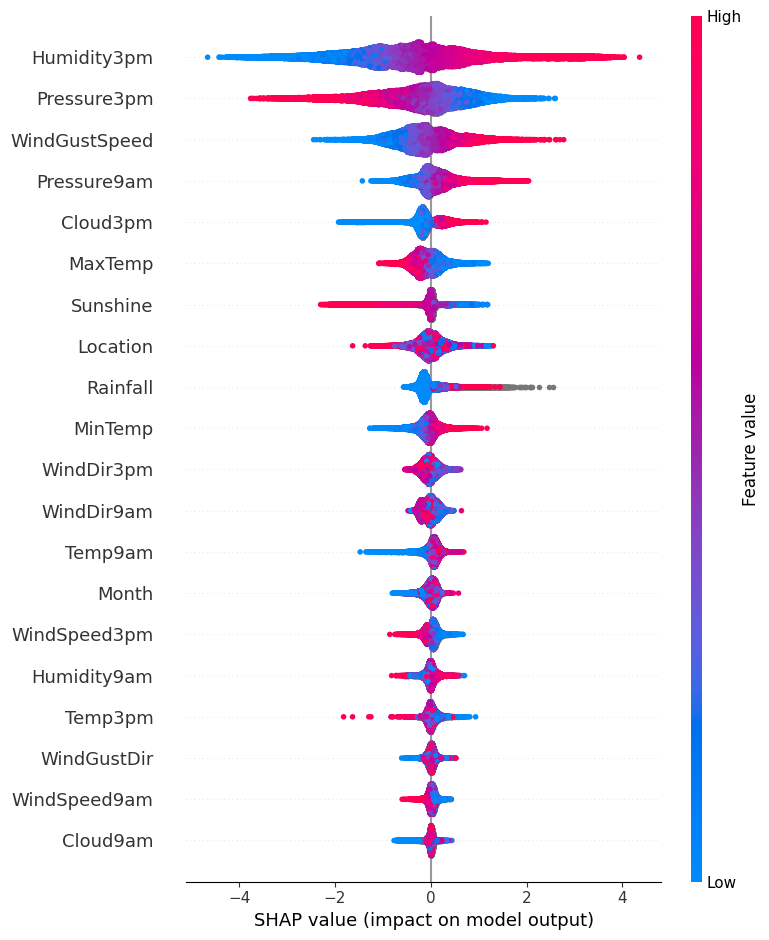

In [20]:
# Initialize TreeExplainer
explainer = shap.TreeExplainer(model)
# Calculate Test Data's SHAP value
shap_values = explainer.shap_values(X_test)

# Showing the average of each feature
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar",color='red')

# Showing size of feature and the impact of result
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)

plt.show()

**Observation:**

The first graph is showing the impact rate if each feature. Sorting from the highest to the lowest. We could found that the top 3 is Humidity3p,Pressure3pm, and Sunshine.

The second graph's behavior is physically interpretable — high humidity, low pressure, strong winds, and heavy cloud cover all logically drive rain predictions, while high sunshine and high pressure suppress them. This alignment with real-world meteorology suggests the model has learned genuine atmospheric patterns rather than spurious correlations.


##Interactive Visualization:

### Global Impact

In [21]:
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'Feature': X_test.columns, 'Importance': mean_shap}).sort_values(by='Importance')

fig1 = px.bar(shap_df, x='Importance', y='Feature', orientation='h',
             title='<b>Visualization 1: Interactive Feature Importance (SHAP)</b>',
             color='Importance',
             color_continuous_scale='Reds',
             labels={'Importance': 'Mean |SHAP Value| (Impact on Model)'})
fig1.update_layout(template='plotly_white', hovermode='y unified')
fig1.show()

### Local Explanation (SHAP Force Plot)

In [22]:
shap.initjs()
print("Displaying Visualization 2: Interactive Prediction Force Plot...")
# We visualize the first 100 samples for performance; users can hover over the "force" lines
shap.force_plot(explainer.expected_value, shap_values[:100,:], X_test_imputed.iloc[:100,:])

Displaying Visualization 2: Interactive Prediction Force Plot...
